# Rejection Sampling

**Rejection Sampling** is a technique to draw samples from a complex, unnormalized target distribution $\tilde{p}(z)$ that cannot be sampled directly.

## How it works
1. Choose a **proposal distribution** $q(z)$ that is easy to sample from and covers the support of $\tilde{p}(z)$.
2. Find a constant $k$ such that $k\,q(z) \geq \tilde{p}(z)$ for all $z$.
3. For each candidate $z_0 \sim q(z)$, accept it with probability $\displaystyle\frac{\tilde{p}(z_0)}{k\,q(z_0)}$.

The accepted samples are distributed according to the normalized version of $\tilde{p}(z)$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


## Target & Proposal Distributions

**Unnormalized target** — a multimodal density:

$$\tilde{p}(z) = \exp\!\left(-\tfrac{1}{2}(z-2)^2\right) + 0.5\,\exp\!\left(-0.2\,(z+3)^2\right)\sin^2(3z)$$

| Component | Description |
|---|---|
| $\exp(-\frac{1}{2}(z-2)^2)$ | Gaussian bump centered at $z = 2$ |
| $0.5\,\exp(-0.2(z+3)^2)\sin^2(3z)$ | Oscillatory modulated Gaussian near $z = -3$ |

**Proposal distribution**: $q(z) = \mathcal{N}(z \mid 0,\; 16)$ — a wide Gaussian ($\sigma=4$) that envelopes the target.

**Bounding constant**: $k = 1.1 \times \max_z \frac{\tilde{p}(z)}{q(z)}$, computed over a dense grid with a 10% safety margin.

**Rejection loop**: Draw $z_0 \sim q$, draw $u_0 \sim \mathrm{Uniform}(0,\; k\,q(z_0))$, accept if $u_0 \leq \tilde{p}(z_0)$.

In [2]:
def p_tilde(z):
    return (
        np.exp(-0.5*(z-2)**2)
        + 0.5*np.exp(-0.2*(z+3)**2)*np.sin(3*z)**2
    )


from scipy.stats import norm

def q(z):
    return norm.pdf(z, loc=0, scale=4)

def sample_q():
    return np.random.normal(0, 4)

z_grid = np.linspace(-15, 15, 100000)
k = np.max(p_tilde(z_grid) / q(z_grid))
k *= 1.1  # safety margin

def rejection_sampling(N):
    samples = []
    attempts = 0

    while len(samples) < N:
        z0 = sample_q()
        u0 = np.random.uniform(0, k * q(z0))
        attempts += 1

        if u0 <= p_tilde(z0):
            samples.append(z0)

    return np.array(samples), attempts

samples, attempts = rejection_sampling(10000)
print(f"Acceptance rate: {len(samples)/attempts:.3f}")


Acceptance rate: 0.277


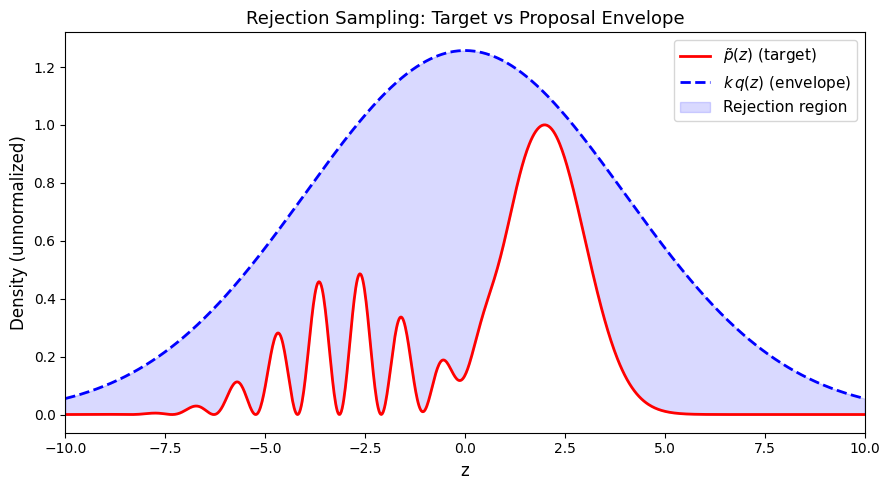

Bounding constant k = 12.6027
Saved to images/rejection_sampling_envelope.png


In [3]:
# Plot the proposal envelope vs target density
z_plot = np.linspace(-10, 10, 1000)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(z_plot, p_tilde(z_plot), 'r', lw=2, label=r"$\tilde{p}(z)$ (target)")
ax.plot(z_plot, k * q(z_plot), 'b--', lw=2, label=r"$k\,q(z)$ (envelope)")
ax.fill_between(z_plot, p_tilde(z_plot), k * q(z_plot), alpha=0.15, color='blue',
                 label="Rejection region")
ax.set_xlabel("z", fontsize=12)
ax.set_ylabel("Density (unnormalized)", fontsize=12)
ax.set_title("Rejection Sampling: Target vs Proposal Envelope", fontsize=13)
ax.legend(fontsize=11)
ax.set_xlim(-10, 10)
fig.tight_layout()
fig.savefig("images/rejection_sampling_envelope.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Bounding constant k = {k:.4f}")
print(f"Saved to images/rejection_sampling_envelope.png")

## Visualization

The histogram of accepted samples (normalized to density) is overlaid with the **true target density** $\tilde{p}(z)$ normalized via numerical integration (`np.trapz`).

A close match between the histogram and the red curve confirms correct sampling.

### Limitations
- **High dimensions**: Acceptance rate drops exponentially — prefer MCMC or Importance Sampling.
- **Grid-based $k$**: A coarse grid or sharp spikes could underestimate $k$ and bias results.
- The 10% safety margin is a practical heuristic, not a formal guarantee.

(array([0.00147366, 0.00147366, 0.00147366, 0.00221049, 0.00073683,
        0.        , 0.00147366, 0.00221049, 0.00589465, 0.0095788 ,
        0.00589465, 0.00368415, 0.        , 0.00073683, 0.00736831,
        0.0191576 , 0.03905203, 0.03094689, 0.01989443, 0.01326295,
        0.00147366, 0.01105246, 0.02947323, 0.05452548, 0.0670516 ,
        0.07147258, 0.0383152 , 0.00810514, 0.00073683, 0.03021006,
        0.06631477, 0.11052462, 0.12599806, 0.1053668 , 0.05157815,
        0.00810514, 0.00368415, 0.04863083, 0.09799849, 0.1341032 ,
        0.12526123, 0.08989335, 0.03536788, 0.00368415, 0.01105246,
        0.04568351, 0.08326188, 0.10315631, 0.08399871, 0.03463105,
        0.01399978, 0.00221049, 0.01547345, 0.04052569, 0.047894  ,
        0.05231498, 0.05378865, 0.03610471, 0.03684154, 0.04715717,
        0.06484111, 0.08178822, 0.10315631, 0.10684046, 0.15178714,
        0.14294517, 0.17757622, 0.18420769, 0.21294409, 0.22915437,
        0.27262739, 0.26083809, 0.27925886, 0.28

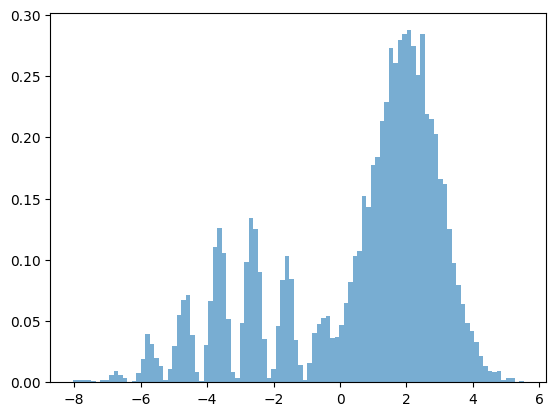

In [4]:
# Plot histogram
plt.hist(samples, bins=100, density=True, alpha=0.6, label="Samples")

# # Plot true (unnormalized) density
# z_plot = np.linspace(-10, 10, 1000)
# plt.plot(z_plot, p_tilde(z_plot)/np.trapezoid(p_tilde(z_plot), z_plot),
#          'r', lw=2, label="Target density")

# plt.legend()
# plt.xlabel("z")
# plt.ylabel("Density")
# plt.title("Rejection Sampling from a Strange Distribution")
# plt.show()


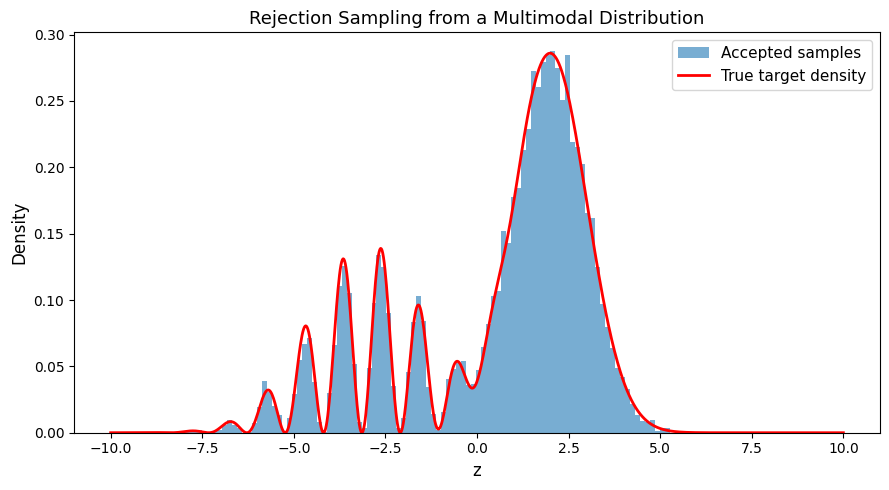

Saved to images/rejection_sampling_result.png


In [5]:
# Compare the histogram of samples to the true density
z_plot = np.linspace(-10, 10, 1000)
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(samples, bins=100, density=True, alpha=0.6, label="Accepted samples")
ax.plot(z_plot, p_tilde(z_plot)/np.trapezoid(p_tilde(z_plot), z_plot),
         'r', lw=2, label="True target density")
ax.legend(fontsize=11)
ax.set_xlabel("z", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("Rejection Sampling from a Multimodal Distribution", fontsize=13)
fig.tight_layout()
fig.savefig("images/rejection_sampling_result.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to images/rejection_sampling_result.png")